In [1]:
import json
from pathlib import Path
from datetime import datetime
from typing import Tuple, Dict

from src.minbpe import RegexTokenizer
from src.gpt import GPTLanguageModel

import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
def now():
    return datetime.now().astimezone().strftime('%FT%T%:z')

class FineTuningDataset(Dataset):
    def __init__(self, data: torch.Tensor, device: torch.device, padding_token: int):
        self.data = data
        self.device = device
        self.padding_token = padding_token

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        sample = self.data[index]
        x = sample.to(self.device)
        y = sample[1:].to(self.device)
        padding_tensor = torch.tensor([self.padding_token], device=self.device)
        y = torch.cat((y, padding_tensor))

        return x, y

@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
) -> Dict[str, float]:
    output = {}
    model.eval()

    for split, loader in [('train', train_loader), ('val', val_loader)]:
        losses = []
        for x, y in loader:
            with torch.no_grad():
                _, loss = model(x, y)
            losses.append(loss.item())
        output[split] = sum(losses) / len(losses)

    model.train()
    return output

In [ ]:
tokenizer_dir = Path("data") / "tokenizer"
checkpoint_dir = Path("data") / "ch04_checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

In [3]:
tokenizer = RegexTokenizer()
tokenizer.load(model_file=str(tokenizer_dir / "tokenizer.model"))

train_tensor = torch.load(tokenizer_dir /'ch04_train.ft.pt')
val_tensor = torch.load(tokenizer_dir /'ch04_validation.ft.pt')

In [4]:
#block_size = 256 # ch02: 256, ch03: 512
#n_embd = 512
#n_head = 8
#n_layer = 4
#dropout = 0.2
#vocab_size = len(tokenizer.vocab)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
padding_token = -100
learning_rate = 6e-5

batch_size = 64
iter_start, max_iters = 1, 20
eval_interval = 20

ckpt_files = sorted(
    checkpoint_dir.glob("checkpoint_*.pt"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

if len(ckpt_files) > 0:
    checkpoint_path = ckpt_files[0]
    iter_start = int(checkpoint_path.name.replace("checkpoint_", "").replace(".pt", "")) + 1
else:
    checkpoint_path = Path("data") / "ch02_checkpoints" / "checkpoint_001-061000.pt"

print(f"load checkpoint: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, weights_only=True, map_location=device)
parameters = checkpoint['meta']['parameters']

load checkpoint: data/ch02_checkpoints/checkpoint_001-061000.pt


In [5]:
model = GPTLanguageModel(
    vocab_size=parameters['vocab_size'],
    block_size=parameters['block_size'],
    n_embd=parameters['n_embd'],
    n_head=parameters['n_head'],
    n_layer=parameters['n_layer'],
    dropout=parameters['dropout'],
    ignore_index=tokenizer.special_tokens["<|padding|>"],
    device=device,
)

model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

model.load_state_dict(checkpoint["model_state_dict"])

num_parameters = sum(p.numel() for p in model.parameters()) / 1e6
print(f'--> {num_parameters:_.3}M parameters')
# print_model_structure(model)

--> 13.8M parameters


In [6]:
input_tokens = tokenizer.encode("hello, world", allowed_special="all")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)
    print(tokenizer.decode(output[0].tolist()))

_ = model.train()

hello, world was tower the rules and similarities of Mandalin who conformed however, the adventures of the Lez-Roman-Pacific Republic, banded in their school band activities. They exhibited various looking methods, including the qualities of archetypes, including music,


OptimizedModule(
  (_orig_mod): GPTLanguageModel(
    (token_embedding_table): Embedding(1029, 512)
    (position_embedding_table): Embedding(256, 512)
    (blocks): Sequential(
      (0): Block(
        (self_attention): MultiHeadAttention(
          (heads): ModuleList(
            (0-7): 8 x Head(
              (key): Linear(in_features=512, out_features=64, bias=False)
              (query): Linear(in_features=512, out_features=64, bias=False)
              (value): Linear(in_features=512, out_features=64, bias=False)
              (dropout): Dropout(p=0.2, inplace=False)
            )
          )
          (projection): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (feed_forward): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=512, out_features=2048, bias=True)
            (1): ReLU()
            (2): Linear(in_features=2048, out_features=512, bias=True)
            (3): Drop

In [7]:
train_dataset = FineTuningDataset(data=train_tensor, device=device, padding_token=padding_token)
val_dataset = FineTuningDataset(data=val_tensor, device=device, padding_token=padding_token)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size)

train_losses, val_losses = [], []

In [ ]:
for iteration in range(iter_start, max_iters+1):
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Evaluation
        if batch_idx % eval_interval == 0 or batch_idx == len(train_loader) - 1:
            losses = estimate_loss(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            print("{} iteration={:03}, step={:07_}, train_loss={:.3f}, validation_loss={:.3f}".format(
                now(), iteration, batch_idx, losses['train'], losses['val'],
            ))

        # Training step
        logits, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    checkpoint_prefix = str(checkpoint_dir / f"checkpoint_{iteration:06}")

    meta = {
        'created_at': now(),
        'parameters': parameters,
        "epoch": iteration,
        'train_loss': train_losses[-1],
        'validation_loss': val_losses[-1],
    }

    checkpoint = {
        'meta': meta,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }

    with open(checkpoint_prefix + ".json", 'w', encoding='utf-8') as f:
        json.dump(meta, f, ensure_ascii=False, indent=4)

    torch.save(checkpoint, checkpoint_prefix+".pt")
    print(f"{now()} saved checkpoint: {checkpoint_prefix}.pt, loss: {loss_val:.3f}")

2025-09-01T18:16:14+08:00 iteration=001, step=000_000, train_loss=2.456, validation_loss=3.204
2025-09-01T18:17:04+08:00 iteration=001, step=000_020, train_loss=1.915, validation_loss=2.604
2025-09-01T18:17:41+08:00 iteration=001, step=000_040, train_loss=1.796, validation_loss=2.485
2025-09-01T18:18:19+08:00 iteration=001, step=000_060, train_loss=1.729, validation_loss=2.431
2025-09-01T18:18:56+08:00 iteration=001, step=000_080, train_loss=1.704, validation_loss=2.407
2025-09-01T18:19:34+08:00 iteration=001, step=000_100, train_loss=1.689, validation_loss=2.397
2025-09-01T18:20:11+08:00 iteration=001, step=000_120, train_loss=1.677, validation_loss=2.424


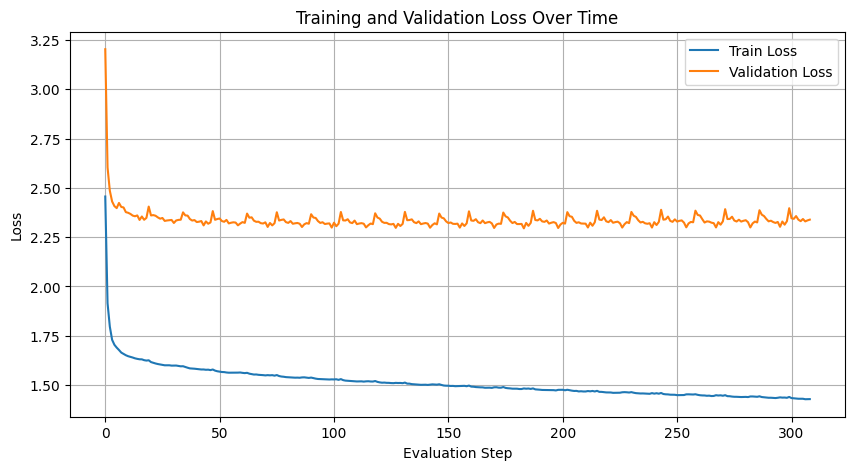

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [35]:
def question_to_tokens(tokenizer, message: str) -> torch.Tensor:
    input_tokens = tokenizer.encode(f"<|startoftext|>{message}<|separator|>", allowed_special="all")

    input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

    return input_tokens

user_message = "What's ChatGPT?"
input_tokens = question_to_tokens(tokenizer, message=user_message)
model_answer = ""

model.eval()
while True:
    output_tokens = model.generate(input_tokens=input_tokens, max_new_tokens=1)
    last_generated_token = output_tokens[0, -1].item()

    if last_generated_token == tokenizer.special_tokens["<|endoftext|>"]:
        break

    input_tokens = torch.cat((input_tokens, output_tokens[:, -1:]), dim=1)

    #print("~~~", input_tokens[0])
    model_answer += tokenizer.decode([last_generated_token])

    #if len(output_tokens[0]) > parameters['block_size']:
    if len(input_tokens[0]) > parameters['block_size']:
        input_tokens = input_tokens[:, -parameters['block_size']:]

print(f"User: {user_message}")
print(f"Assistant: {model_answer}")

User: What's ChatGPT?
Assistant: As I am an AI language model, what do you think? I think I say it's spying The chatbot was like?

I was looking for new adventures for a new restaurant.
The alleged option would be that I could most likely have become experienced this so earlier to have rescue!

That's like making a plan, revised, and hidden triangle. Also, I don't know what it's about. So ghosts our ass
For a magic system, will have some rogue option:
A magic system, in a magical world that does not have the ability to converge in any future.
I prefer energy levels.
Werch is a small assistant that is quite good in a way that's quite fun,
But if a compass of the story's eyes open could be truly.
